<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/2027GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
os.environ["TORCHINDUCTOR_FREEZE_PCH"] = "1"
# Also force Inductor to use a fresh directory if the previous one is locked
os.environ["TORCHINDUCTOR_CACHE_DIR"] = "/tmp/torch_compile_fresh"

In [28]:
#mit joshuah.rainstar@gmail.com 2026
import math
import copy
from dataclasses import dataclass
from typing import Optional, Tuple, List
import torch
import torch.nn as nn
import torch.nn.functional as F

class LELU(nn.Module):
    def __init__(self):
        super().__init__()
        self.scale = math.pi / math.sqrt(3.0) #logistic CDF matched scale beats gelu and is less expensive

    def forward(self, x):
        return x * torch.sigmoid(self.scale * x)



class RoPE(nn.Module):
    def __init__(self, dim, max_len=4096):
        super().__init__()
        self.dim = dim
        self.max_len = max_len

        w_max = torch.pi / 2 #highest frequency- one rotation in 4 tokens
        w_min = torch.pi / (max_len) #this sets the lowest scale to that sufficient to resolve needle at depth.
        #most effectively, set your context size to more than you ever intend to handle
        B = 10
        setfreqs_hi = torch.logspace(
                    start=math.log(w_min,B),
                    end=math.log(w_max,B),
                    steps=(dim // 4),
                    base=B
                )


        setfreqs_lo = w_max - torch.logspace(
            start=math.log(w_min,B),
            end=math.log(w_max,B),
            steps=(dim // 4) + 1,
            base=B
        )[:-1] # Drop last to match size and allow a smooth continuation

                # Combine
        setfreqs = torch.cat((setfreqs_hi, setfreqs_lo))
        inv_freq, _ = torch.sort(setfreqs,descending=True) #this give us a sigmoidal distribution of frequencies.
        #many large, many small, few near the midpoint.

        t = torch.arange(max_len).float()
        freqs = torch.einsum('i,j->ij', t, inv_freq)
        self.register_buffer('cos_cached', freqs.cos())
        self.register_buffer('sin_cached', freqs.sin())

    def get_embeddings(self, positions, device):
        positions = positions.clamp(0, self.max_len - 1).long()
        cos = F.embedding(positions, self.cos_cached).unsqueeze(0).unsqueeze(0) # [1, 1, T, D]
        sin = F.embedding(positions, self.sin_cached).unsqueeze(0).unsqueeze(0)
        return cos, sin

    def forward(self, x, positions=None):
        # x: (B, H, T, D) where D = self.dim (head_dim)
        if positions is None:
            T = x.shape[-2]
            positions = torch.arange(T, device=x.device)

        cos, sin = self.get_embeddings(positions, x.device)
        # cos, sin: [1, 1, T, D//2]

        D = x.shape[-1]
        mid = D // 2
        h1 = x[..., :mid]   # first half of dimensions
        h2 = x[..., mid:]   # second half of dimensions

        # Adjacent pairing within each half:
        # h1 pairs: (h1[0],h1[1]), (h1[2],h1[3]), ...
        # h2 pairs: (h2[0],h2[1]), (h2[2],h2[3]), ...
        #
        # h1 gets sign-flipped convention (sin term adds instead of subtracts)
        # h2 gets standard convention
        #
        # This is achieved by negating the "b" element of each pair in h1
        # before feeding into the standard rotation formula.

        # For h1: negate odd-indexed elements, apply rotation, un-negate
        # Equivalent to: the kernel contribution for h1 pairs becomes
        #   S * cos(w*d) + A * sin(w*d)
        # instead of
        #   S * cos(w*d) - A * sin(w*d)

        # Extract paired elements for h1
        h1_a = h1[..., 0::2]   # even indices (the "real" part)
        h1_b = h1[..., 1::2]   # odd indices (the "imaginary" part)

        # Extract paired elements for h2
        h2_a = h2[..., 0::2]
        h2_b = h2[..., 1::2]

        # Split cos/sin for the two halves' frequency ranges
        # First D//4 frequencies go to h1, last D//4 to h2
        n_pairs_per_half = mid // 2  # D//4
        cos1 = cos[..., :n_pairs_per_half]
        sin1 = sin[..., :n_pairs_per_half]
        cos2 = cos[..., n_pairs_per_half:]
        sin2 = sin[..., n_pairs_per_half:]

        # H1: flipped convention (negate b before rotation)
        # Standard rotation on (a, -b):
        #   out_a = a * cos - (-b) * sin = a * cos + b * sin
        #   out_b_neg = a * sin + (-b) * cos = a * sin - b * cos
        # Then un-negate b: out_b = -(a * sin - b * cos) = -a * sin + b * cos
        out_h1_a = h1_a * cos1 + h1_b * sin1
        out_h1_b = -h1_a * sin1 + h1_b * cos1

        # H2: standard convention
        #   out_a = a * cos - b * sin
        #   out_b = a * sin + b * cos
        out_h2_a = h2_a * cos2 - h2_b * sin2
        out_h2_b = h2_a * sin2 + h2_b * cos2

        # Reassemble: interleave a,b back into adjacent pairs
        out_h1 = torch.stack([out_h1_a, out_h1_b], dim=-1).flatten(-2)
        out_h2 = torch.stack([out_h2_a, out_h2_b], dim=-1).flatten(-2)

        return torch.cat([out_h1, out_h2], dim=-1)



class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 2 * config.n_embd, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(2 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x

class MLP_bottle(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd,  config.n_embd//2, bias=config.bias)
        self.act = LELU()
        self.c_proj  = nn.Linear(config.n_embd//2, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.act(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_heads = config.n_head
        self.n_embd = config.n_embd
        dim = config.n_embd
        self.head_dim = dim // self.n_heads
        self.skew_basis = nn.Parameter(
            torch.randn(self.n_heads, self.head_dim, self.head_dim) * 0.02
        )


        self.q_proj = nn.Linear(dim,dim,bias=False)
        self.v_proj = nn.Linear(dim,dim,bias=False)
        self.o_proj = nn.Linear(dim,dim,bias=False)

        nn.init.eye_(self.q_proj.weight) # Identity Init
        self.v_sink_residual = nn.Parameter(torch.zeros(1, 1, 1, self.head_dim))
        self.v_sink_basis = nn.Parameter(torch.zeros(1, self.n_heads, 1, self.head_dim))

        self.mask = None #set in GPT main at model time to ensure its on GPU
        self.rope = config.rope
        limit = config.block_size // 2

        self.sd_alpha = 0.3
        self.sd_sigma = config.block_size / 2.0
        alphas = torch.linspace(0, 1, self.n_heads).view(1, self.n_heads, 1, 1)
        self.register_buffer('k_alpha', alphas)
        self.o_proj = nn.Linear(dim, dim, bias=False)
        self.p_skew_basis = nn.Parameter(
            torch.randn(self.n_heads, self.head_dim, self.head_dim) * 0.02
        )
        # gate to blend O and P projections -- learned per head
        self.op_gate = nn.Parameter(torch.zeros(1, self.n_heads, 1, 1))  # sigmoid -> 0.5 init

        # mixing tensor projection: score structure -> directional bias
        # this is small: head_dim -> head_dim, per-head aware
        self.mix_proj = nn.Linear(self.head_dim, self.head_dim, bias=False)


    def get_p_matrix(self):
        skew = self.p_skew_basis - self.p_skew_basis.transpose(-1, -2)
        return torch.matrix_exp(skew)

    def get_orthogonal_matrix(self):
        # A = M - M.T (Skew symmetric)
        # We broadcast the transpose over the last two dims
        skew = self.skew_basis - self.skew_basis.transpose(-1, -2)

        # Matrix Exp for each head independently
        # Result: [H, D_h, D_h]
        return torch.matrix_exp(skew)

    def forward(self, x):
        B, T, C = x.shape
        H, D = self.n_heads, self.head_dim

        # Get per-head rotations
        Rs = self.get_orthogonal_matrix() # [H, D, D]

        # 1. Reshape q_proj weight to [H, D_h, Dim]
        W_q = self.q_proj.weight.view(self.n_heads, self.head_dim, -1)

        # 2. Rotate each head's slice of the weight matrix
        # [H, D, D] @ [H, D, Dim] -> [H, D, Dim]
        W_k_heads = Rs @ W_q

        # 3. Flatten back to [Dim, Dim] for the linear layer
        # This effectively constructs a Block-Diagonal W_k
        W_k = W_k_heads.view(-1, self.n_embd)

        q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        k = F.linear(x, W_k).view(B, T, H, D).transpose(1, 2)


        v = self.v_proj(x).view(B, T, H, D).transpose(1, 2)


        q = F.rms_norm(q, (D,)) #never ever norm k, you stupid fuck

        q = self.rope(q)
        k = self.rope(k)

        # Soft Attention
        scores = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(D))

        mask = self.mask[:, :, :T, :T]

        soft_scores = F.softplus(scores)
        # STE: Forward sets small/neg values to 0, Backward ignores the zeroing
        # Values < 1e-6 do not participate in mass/scaling but receive gradients
        threshold = 1e-6
        pruned_scores = torch.where(soft_scores < threshold, torch.zeros_like(soft_scores), soft_scores)
        soft_scores = soft_scores + (pruned_scores - soft_scores).detach()

        soft_scores = soft_scores.masked_fill(mask == 0, 0.0) #prevent cheating here

        if self.training:
            # Create Distance Matrix [T, T]
            # dist[i, j] = i - j
            # We only care about positive distances (j <= i), which causal mask handles
            indices = torch.arange(T, device=x.device)
            dist = indices.view(-1, 1) - indices.view(1, -1)

            # Gaussian Decay Profile
            # P(drop) is high when dist is small (Recent)
            # P(drop) is low when dist is large (Distant)
            # We clamp dist to 0 to avoid NaNs, though masking handles it


            # Broadcast probabilities to batch/heads [1, 1, T, T]
            dist = dist.float().clamp(min=0)
            drop_probs = self.sd_alpha * torch.exp(-(dist**2) / (2 * self.sd_sigma**2))

            # Align dimensions: [1, 1, T, T]
            drop_probs = drop_probs.unsqueeze(0).unsqueeze(0)

            #dont allow damage to the first half, regardless
            #limited suppot positions do not get eroded
            limit = T // 2
            absolute_cutoff_mask = (dist > limit)
            drop_probs = drop_probs.masked_fill(absolute_cutoff_mask, 0.0)
            #Expand BEFORE sampling to ensure atomic independence
            # We must explicitly expand to [B, H, T, T] so Bernoulli rolls
            # a unique die for every single head and batch item.
            drop_probs_expanded = drop_probs.expand(B, H, T, T)

            # Generate Bernoulli Mask on the full tensor
            keep_mask = torch.bernoulli(1.0 - drop_probs_expanded).bool()

            # Apply Dropout
            soft_scores = soft_scores.masked_fill(~keep_mask, 0.0)
            #what this does is force attention to learn deeper patterns.
            #it also dramatically improves needles- it finds needles with same num batches,
            #despite randomly hiding needles. so it technically sees needle far sooner.


        soft_sums = soft_scores.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (soft_sums + 1e-6), max=1.0)
        attn = soft_scores * scale
        attn = torch.nan_to_num(attn, nan=0.0)

            # ===== Replace everything from y_context = attn @ v onward =====

        y_context = attn @ v  # (B, H, T, D)

        # === Mixing tensor: variance of the attended distribution ===
        v_sq = attn @ (v * v)  # E[v^2] under attention weights
        mix_variance = F.relu(v_sq - y_context * y_context)  # Var[v] per dim, (B, H, T, D)

        # Project mix_variance into mixing directions
        # mix_proj learns to read the variance profile and output the principal mixing axis
        mix_dir = self.mix_proj(mix_variance)  # (B, H, T, D)
        mix_dir = F.normalize(mix_dir, dim=-1)

        # === Residual sink ===
        current_mass = attn.sum(dim=-1, keepdim=True)
        residual_weight = 1.0 - F.sigmoid(current_mass)
        y_res = residual_weight * self.v_sink_residual

        # === XSA ===
        vn = F.normalize(v, dim=-1)
        y_context = y_context - (y_context * vn).sum(dim=-1, keepdim=True) * vn

        y = F.rms_norm(y_context, (D,)) + self.v_sink_basis + y_res
        # y is (B, H, T, D)

        # === O/P decomposition along mixing tensor eigenvectors ===
        # Decompose y into component along mix_dir and component orthogonal to it
        # mix_dir is the dominant eigenvector of the mixing stress
        y_along = (y * mix_dir).sum(dim=-1, keepdim=True) * mix_dir  # projection onto mixing axis
        y_ortho = y - y_along  # complement

        # Flatten both to (B, T, C) for projection
        y_along_flat = y_along.transpose(1, 2).contiguous().view(B, T, -1)
        y_ortho_flat = y_ortho.transpose(1, 2).contiguous().view(B, T, -1)

        # O projects the component along the mixing direction
        # P (orthogonal rotation of O) projects the orthogonal complement
        Rs_p = self.get_p_matrix()  # (H, D, D)
        W_o_heads = self.o_proj.weight.view(self.n_heads, self.head_dim, -1)
        W_p_heads = Rs_p @ W_o_heads
        W_p = W_p_heads.view(-1, self.n_embd)

        o_out = self.o_proj(y_along_flat)      # mixing-axis content through O
        p_out = F.linear(y_ortho_flat, W_p)    # orthogonal content through P

        return o_out + p_out


def norm(x):
    return F.rms_norm(x, (x.size(-1),))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.attn = Attention(config)
        self.ffn = MLP(config)
        self.attn_dir = MLP_bottle(config)
        self.ffn_dir = config.bottle #shared direction

    def forward(self, x):
        z =  self.attn(norm( x))
        vn = F.normalize(self.attn_dir(norm(x)), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = (q + z)

        e = self.ffn(norm(x))
        vn = F.normalize(self.ffn_dir(norm(x)), dim=-1)
        q = x - (x * vn).sum(dim=-1, keepdim=True) * vn
        x = (q + e)

        return x

@dataclass
class GPTConfig:
    block_size: int = 1024
    vocab_size: int = 66
    n_layer: int = 4
    n_head: int = 4

    n_embd: int = 768
    dropout: float = 0.0
    bias: bool = False
    rope: nn.Module = None
    bottle: nn.Module = None
    device: str = "cuda"

class SoftplusCELoss(nn.Module):
    def __init__(self, ignore_index=-1, label_smoothing=0.0):
        super().__init__()
        self.ignore_index = ignore_index
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        # logits: (B, V) or (B, T, V)
        # targets: (B,) or (B, T)
        flat_logits = logits.view(-1, logits.size(-1))
        flat_targets = targets.view(-1)

        mask = flat_targets != self.ignore_index
        flat_logits = flat_logits[mask]
        flat_targets = flat_targets[mask]

        if flat_targets.numel() == 0:
            return flat_logits.sum() * 0.0

        # softplus "probabilities" -- same mechanism as your attention
        sp = F.softplus(flat_logits)

        threshold = 1e-6
        pruned = torch.where(sp < threshold, torch.zeros_like(sp), sp)
        sp = sp + (pruned - sp).detach()  # STE

        sp_sum = sp.sum(dim=-1, keepdim=True)
        scale = torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)
        probs = sp * scale  # sub-unity simplex

        # gather target probs
        target_probs = probs.gather(1, flat_targets.unsqueeze(1)).squeeze(1)

        # NLL on the softplus-normalized probs
        loss = -torch.log(target_probs + 1e-8)

        if self.label_smoothing > 0.0:
            # smooth term: average negative log-prob across vocab
            smooth_loss = -torch.log(probs + 1e-8).mean(dim=-1)
            loss = (1.0 - self.label_smoothing) * loss + self.label_smoothing * smooth_loss

        return loss.mean()

class SubspaceUnembed(nn.Module):
    def __init__(self, d_model, vocab_size, n_slices=4):
        super().__init__()
        self.n_slices = n_slices
        self.sub_d = d_model // n_slices
        assert d_model % n_slices == 0

        # each slice gets its own direction carver and linear
        self.dir_nets = nn.ModuleList([
            nn.Linear(d_model, d_model, bias=False)
            for _ in range(n_slices)
        ])
        self.projs = nn.ModuleList([
            nn.Linear(d_model, vocab_size, bias=False)
            for _ in range(n_slices)
        ])

    def forward(self, h):
        logits = 0
        residual = h
        for i in range(self.n_slices):
            vn = F.normalize(self.dir_nets[i](h), dim=-1)
            # carve out component along vn
            component = (residual * vn).sum(dim=-1, keepdim=True) * vn
            residual = residual - component
            # this slice's logit contribution
            logits = logits + self.projs[i](component)

        # residual gets default projection through last linear
        logits = logits + self.projs[-1](residual)
        return logits

class LayerCache:
    """Autograd-safe cache using a list internally, pre-allocated buffer for the view."""
    def __init__(self):
        self.entries = []

    def push(self, x):
        self.entries.append(x)

    def get(self):
        if len(self.entries) == 0:
            return None
        return torch.stack(self.entries, dim=0)  # (N, B, T, D)

    def reset(self):
        self.entries = []


class BlockWithMemory(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.n_layer = config.n_layer
        self.res_proj = nn.ParameterList([
            nn.Parameter(torch.zeros(config.n_embd)) for _ in range(config.n_layer)
        ])

    def softplusmax(self, logits, dim=0):
        sp = F.softplus(logits)
        sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
        sp_sum = sp.sum(dim=dim, keepdim=True)
        scale = torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)
        return sp * scale

    def _attn_res(self, x, query, cache_view):
        V = torch.cat([cache_view, x.unsqueeze(0)], dim=0)  # (N+1, B, T, D)
        K = F.rms_norm(V, (V.size(-1),))
        logits = torch.einsum("d, n b t d -> n b t", query, K)
        weights = self.softplusmax(logits, dim=0)  # (N+1, B, T)
        return torch.einsum("n b t, n b t d -> b t d", weights, V)

    def _block_fn(self, block, x):
        return block(x)

    def forward(self, block, x, i, cache_view):
        if cache_view is not None:
            query = self.res_proj[i]
            x_res = torch.utils.checkpoint.checkpoint(
                self._attn_res, x, query, cache_view,
                use_reentrant=False
            )
        else:
            x_res = x

        x_out = torch.utils.checkpoint.checkpoint(
            self._block_fn, block, x_res,
            use_reentrant=False
        )
        return x_out


class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.rope = RoPE(config.n_embd // config.n_head, max_len=config.block_size)
        self.config.rope = self.rope
        self.bottle= MLP_bottle(config)
        self.config.bottle = self.bottle

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h = nn.ModuleList([Block(self.config) for _ in range(config.n_layer)]),
        ))

        mask_tensor = torch.tril(torch.ones(config.block_size, config.block_size)).view(1, 1, config.block_size, config.block_size).to(device=self.config.device)
        self.register_buffer("mask", mask_tensor)
        for block in self.transformer.h:
          block.attn.mask = self.mask #set here
        self.criterion = SoftplusCELoss(ignore_index=-1)
        self.lm_head = SubspaceUnembed(config.n_embd, config.vocab_size)
        self.block_mem = BlockWithMemory(config)
        self.cache = LayerCache()



        print("number of parameters: %.2fM" % (self.get_num_params()/1e6,))

    def get_num_params(self, non_embedding=True):
        n_params = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n_params -= self.transformer.wte.weight.numel()
        return n_params

    def forward(self, idx, targets=None):
        b, T = idx.size()
        x = self.transformer.wte(idx)

        x = norm(x)


        self.cache.reset()
        for i, block in enumerate(self.transformer.h):
             x = self.block_mem(block, x, i, self.cache.get())
             self.cache.push(x)


        x = norm(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = self.criterion(logits, targets)
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None

        return logits, loss



    def softplusmax(logits, temperature=1.0):
        sp = F.softplus(logits / temperature)
        sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
        sp_sum = sp.sum(dim=-1, keepdim=True)
        return sp * torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)
    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        past_key_values = None
        for _ in range(max_new_tokens):
            # If we have cache, we only feed the very last token
            idx_cond = idx[:, -1:] if past_key_values else idx

            # Pass past_key_values explicitly
            logits, past_key_values = self(idx_cond, targets=None, past_key_values=past_key_values)

            logits = logits[:, -1, :]
            probs = softplusmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)
        return idx

In [2]:


import requests, os

base_url = "https://huggingface.co/datasets/cambridge-climb/BabyLM/resolve/main/clean/10M/"
target_dir = "./babylm_10m_cleaned"
os.makedirs(target_dir, exist_ok=True)

file_names = [
    "aochildes.txt",
    "cbt.txt",
    "children_stories.txt",
    "gutenberg.txt",
    "qed.txt",
    "simple_wikipedia.txt",
    "switchboard.txt",
    "wikipedia.txt"
]

# Optional addition: Shakespeare from another dataset
shakespeare_url = "https://raw.githubusercontent.com/karpathy/char-rnn/refs/heads/master/data/tinyshakespeare/input.txt"
shakespeare_fname = "shakespeare.txt"

# Combined download logic
all_files = [(base_url + fname, fname) for fname in file_names]
all_files.append((shakespeare_url, shakespeare_fname))  # Add Shakespeare


# Download loop
for url, fname in all_files:
    out_path = os.path.join(target_dir, fname)
    print(f"📥 Downloading {fname}...")
    resp = requests.get(url)
    if resp.status_code == 200:
        with open(out_path, "w", encoding="utf-8") as f:
            f.write(resp.text)
    else:
        print(f"❌ Failed to download {fname} ({resp.status_code})")

print(f"✅ Done. Files saved to {target_dir}")

📥 Downloading aochildes.txt...
📥 Downloading cbt.txt...
📥 Downloading children_stories.txt...
📥 Downloading gutenberg.txt...
📥 Downloading qed.txt...
📥 Downloading simple_wikipedia.txt...
📥 Downloading switchboard.txt...
📥 Downloading wikipedia.txt...
📥 Downloading shakespeare.txt...
✅ Done. Files saved to ./babylm_10m_cleaned


In [4]:
import os
import pickle
import numpy as np

# === Paths ===
source_dir = "./babylm_10m_cleaned"
out_dir    = "./babylm_char_tokenized"
os.makedirs(out_dir, exist_ok=True)

file_names = [
    "shakespeare.txt"#,"aochildes.txt", "cbt.txt", "children_stories.txt", "gutenberg.txt",
    #"qed.txt", "simple_wikipedia.txt", "switchboard.txt", "wikipedia.txt"
]

# === Load and split ===
train_texts, val_texts = [], []
char_set = set()

for fname in file_names:
    with open(os.path.join(source_dir, fname), encoding="utf-8") as f:
        lines = f.readlines()
        n = len(lines)
        split = int(0.9 * n)
        train_part = "".join(lines[:split])
        val_part   = "".join(lines[split:])
        train_texts.append(train_part)
        val_texts.append(val_part)
        char_set.update(train_part)
        char_set.update(val_part)

full_train = "\n".join(train_texts)
full_val   = "\n".join(val_texts)

# === Final vocab ===
char_set = sorted(set(char_set))
vocab_chars = ["<unk>"] + [c for c in char_set if c != "<unk>"]

stoi = {ch: i for i, ch in enumerate(vocab_chars)}
itos = {i: ch for ch, i in stoi.items()}

# === Encode function ===
def encode(text):
    return [stoi.get(c, 0) for c in text]

train_ids = np.array(encode(full_train), dtype=np.uint16)
val_ids   = np.array(encode(full_val),   dtype=np.uint16)

# === Save ===
train_ids.tofile(os.path.join(out_dir, "train.bin"))
val_ids.tofile(os.path.join(out_dir, "val.bin"))

with open(os.path.join(out_dir, "meta.pkl"), "wb") as f:
    pickle.dump({
        "vocab_size": len(stoi),
        "stoi": stoi,
        "itos": itos
    }, f)

print(f"✅ Char tokenizer finalized.")
print(f"🧾 Train tokens: {len(train_ids)} | Val tokens: {len(val_ids)}")
print(f"🔤 Vocab size: {len(stoi)}")

✅ Char tokenizer finalized.
🧾 Train tokens: 1016242 | Val tokens: 99152
🔤 Vocab size: 66


In [ ]:
import shutil, os, tempfile

cache_dir = os.path.join(tempfile.gettempdir(), "torchinductor_joshuahkuttenkuler")
shutil.rmtree(cache_dir, ignore_errors=True)
print("cleared", cache_dir)

cleared /var/folders/7_/98nk8q255lxf2kbxm92j37rh0000gn/T/torchinductor_joshuahkuttenkuler


In [72]:
import os
import pickle
import numpy as np
from torch.utils.data import DataLoader, Dataset
import torch
from torch import nn
import torch.nn.functional as F

device = "cuda" if torch.cuda.is_available() else "cpu"

# === Config ===
data_dir = "./babylm_char_tokenized"  # <- char-tokenized data
block_size = 1024
batch_size = 8

# === Load tokenizer metadata ===
with open(os.path.join(data_dir, 'meta.pkl'), 'rb') as f:
    meta = pickle.load(f)
vocab_size = meta['vocab_size']

# === Load mmap edata (char-level tokens, uint16) ===
train_ids = np.memmap(os.path.join(data_dir, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(data_dir, 'val.bin'),   dtype=np.uint16, mode='r')

# === Efficient GPU Batch Sampler ===
class GPUBatchDataset(Dataset):
    def __init__(self, mmap_file, block_size, batch_size, device, jitter=63, p_aligned=0.5, pad_len=0):
        self.data = mmap_file
        self.block_size = block_size
        self.batch_size = batch_size
        self.device = device
        self.pad_len = int(pad_len)
        self.sample_len = self.block_size + self.pad_len  # X length
        self.total = len(self.data) - self.sample_len - 1
        self.n_blocks = self.total // self.sample_len
        self.jitter = int(jitter)          # small random offset added to aligned start
        self.p_aligned = float(p_aligned)  # mix aligned and jittered

    def __len__(self):
        return self.total // self.batch_size

    def __getitem__(self, idx):
        X = np.empty((self.batch_size, self.sample_len), dtype=np.int64)
        Y = np.empty((self.batch_size, self.block_size), dtype=np.int64)

        for i in range(self.batch_size):
            # === THE FIX ===
            # Pick a TRULY random start index anywhere in the file
            # No grid, no alignment, no "base_block"
            start = np.random.randint(0, self.total)

            X[i] = self.data[start : start + self.sample_len]
            Y[i] = self.data[start + 1 + self.pad_len : start + 1 + self.pad_len + self.block_size]

        return (
            torch.from_numpy(X).to(self.device, non_blocking=True),
            torch.from_numpy(Y).to(self.device, non_blocking=True)
        )


config = GPTConfig(
    vocab_size=len(stoi),
    n_layer=6,
    n_embd=192,
    n_head=6,
    block_size=block_size, # always more then trained
    device = device
)
train_dataset = GPUBatchDataset(train_ids, block_size, batch_size, device, pad_len=0)
# === DataLoader ===
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)
model = GPT(config)
torch.compiler.reset()
model = torch.compile(model)
model = model.to(device)


number of parameters: 2.09M


In [ ]:
state_dict = torch.load("overfitshakespeare_tiny.pt")
model.load_state_dict(state_dict, strict=True) # strict=True confirms the match is perfect
print("Weights loaded successfully.")

In [6]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {num_params}")

Total trainable parameters: 1296792


In [73]:
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)
losses = []
def train_epoch():
    model.train()
    itera = 0
    total_loss = 0
    for xb, yb in train_loader:
          xb, yb = xb[0], yb[0]  # unwrap batch dimension
          optimizer.zero_grad()
          logits, loss = model(xb, yb)
          loss = loss
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()
          total_loss += loss.item()
          losses.append(loss.item())
          print(itera, loss.item())
          itera = itera + 1
    return total_loss / len(train_loader)

# === Run Training ===
num_epochs = 10
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 4.2160797119140625
1 3.6143617630004883
2 3.3752408027648926
3 3.2097079753875732
4 3.088653326034546
5 2.9718141555786133
6 2.936617374420166
7 2.846639394760132
8 2.7581048011779785
9 2.785524845123291
10 2.6905741691589355
11 2.6983678340911865
12 2.6497559547424316
13 2.606036901473999
14 2.6156327724456787
15 2.570201873779297
16 2.5895462036132812
17 2.5921754837036133
18 2.555983066558838
19 2.5550637245178223
20 2.5664072036743164
21 2.514716625213623
22 2.5416629314422607
23 2.552337169647217
24 2.577014446258545
25 2.532231569290161
26 2.544586658477783
27 2.537374973297119
28 2.5330190658569336
29 2.5351686477661133
30 2.523681163787842
31 2.5015432834625244
32 2.514251232147217
33 2.515383243560791
34 2.512129783630371
35 2.509401798248291
36 2.4976775646209717
37 2.4924001693725586
38 2.498124837875366
39 2.488217353820801
40 2.4907031059265137
41 2.468719005584717
42 2.495302677154541
43 2.5212578773498535
44 2.503636360168457
45 2.470836639404297
46 2.499417781829834
4

KeyboardInterrupt: 

Extracting neurons...
Computing 3D Manifold (this may take a moment)...


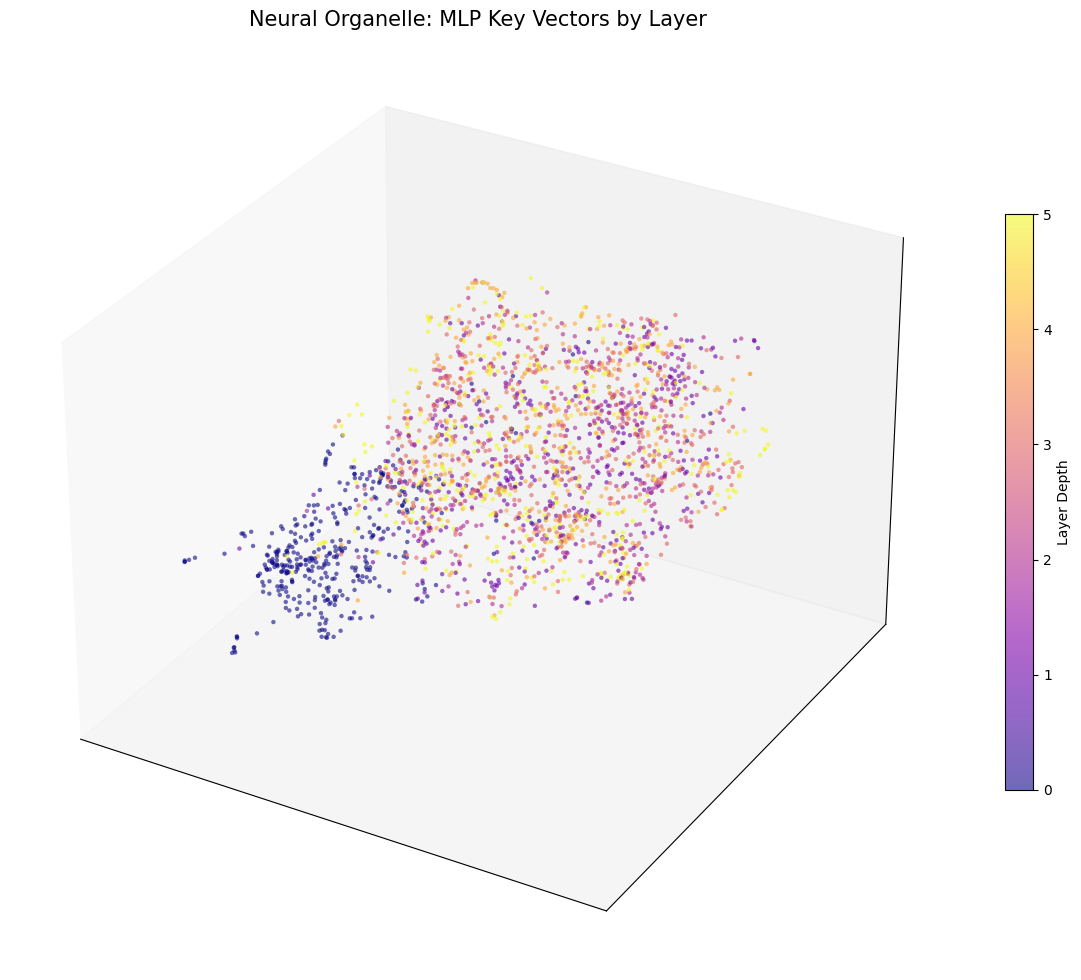

In [74]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import umap # pip install umap-learn

def visualize_organelle(model):
    # 1. Collect all MLP Neurons ("Detectors")
    # In GPT, the MLP up-projection (c_fc) reads from the embedding space.
    # Each row is a "neuron" looking for a specific direction in 128-dim space.

    all_neurons = []
    layer_labels = []

    print("Extracting neurons...")
    for i, block in enumerate(model.transformer.h):
        # Shape: [4 * n_embd, n_embd] -> [512, 128] for your config
        # We view these as 512 distinct vectors in 128-dim space
        weights = block.ffn.c_fc.weight.detach().cpu().numpy()
        all_neurons.append(weights)
        layer_labels.append(np.full(weights.shape[0], i)) # Track which layer owns the neuron

    # Concatenate to shape [Total_Neurons, n_embd]
    # For 4 layers * 512 neurons = 2048 points
    X = np.vstack(all_neurons)
    labels = np.concatenate(layer_labels)

    # 2. UMAP Projection (The "Organelle" Generator)
    # n_neighbors: Controls local vs global structure.
    #   Low (5-15) = fragmentation (many tiny blobs).
    #   High (50-100) = global shape (one big connected organelle).
    # min_dist: Controls how tightly points pack together.
    print("Computing 3D Manifold (this may take a moment)...")
    reducer = umap.UMAP(
        n_neighbors=5,
        min_dist=0.1,
        n_components=5,
        metric='cosine' # Cosine is critical for high-dim semantics
    )
    embedding = reducer.fit_transform(X)

    # 3. Visualization
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Color map matches the layer depth
    scatter = ax.scatter(
        embedding[:, 0],
        embedding[:, 1],
        embedding[:, 2],
        c=labels,
        cmap='plasma',
        s=10,
        alpha=0.6,
        edgecolor='none'
    )

    # Styling to look like the "Twitter render"
    ax.set_facecolor('white')
    ax.grid(False)
    ax.set_title("Neural Organelle: MLP Key Vectors by Layer", fontsize=15)

    # Add a color bar indicating depth
    cbar = plt.colorbar(scatter, ax=ax, shrink=0.6)
    cbar.set_label('Layer Depth')

    # Remove axis ticks for cleaner look
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    plt.tight_layout()
    plt.show()

# Run it
visualize_organelle(model)

In [47]:
for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch()
    print(f"Epoch {epoch:2d} | Train loss: {train_loss:.4f}")

0 1.417931079864502
1 1.4052400588989258
2 1.4233009815216064
3 1.329155683517456
4 1.307770013809204
5 1.4149221181869507
6 1.43716561794281
7 1.3572509288787842
8 1.4463670253753662
9 1.436734914779663
10 1.372399091720581
11 1.407180666923523
12 1.3903058767318726
13 1.4422237873077393
14 1.3997328281402588
15 1.4013761281967163
16 1.4405040740966797
17 1.35276460647583
18 1.388077974319458
19 1.4387601613998413
20 1.403391718864441
21 1.4203035831451416
22 1.4693882465362549
23 1.391839623451233
24 1.3420031070709229
25 1.4336124658584595
26 1.3701093196868896
27 1.406346082687378
28 1.387087106704712
29 1.3435087203979492
30 1.450700283050537
31 1.3580166101455688
32 1.3923895359039307
33 1.3608813285827637
34 1.3543739318847656
35 1.381392240524292
36 1.347062110900879
37 1.283564567565918
38 1.3763905763626099
39 1.3927559852600098
40 1.3840892314910889
41 1.3717164993286133
42 1.355728268623352
43 1.420370101928711
44 1.335754632949829
45 1.4281851053237915
46 1.314322233200073

KeyboardInterrupt: 

In [35]:
%matplotlib inline


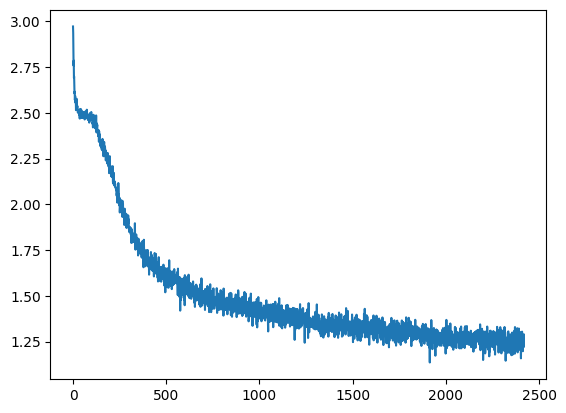

In [75]:
from matplotlib import pyplot as plt

plt.plot(losses[5:])
plt.show()

In [76]:
import numpy as np
import torch
import torch.nn.functional as F

@torch.no_grad()
def eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=None):
    """
    Computes BPC and PPL on random contiguous slices.
    Assumes ?1 the loss returned by model(x, y) is mean NLL per token.
    """
    model.eval()
    if device is None:
        device = next(model.parameters()).device

    total_nll_nat = 0.0
    total_tokens = 0

    for _ in range(max_batches):
        if len(val_ids) <= block_size + 1:
            break

        start = np.random.randint(0, len(val_ids) - block_size - 1)
        x = torch.tensor(val_ids[start:start+block_size], dtype=torch.long, device=device)[None, :]
        y = torch.tensor(val_ids[start+1:start+block_size+1], dtype=torch.long, device=device)[None, :]

        # IMPORTANT: pass y so the model returns a sequence loss
        logits, loss = model(x, y)
        loss=None
        # If model doesn’t return loss for some reason, compute it safely
        if loss is None:
            # Handle both possible logits shapes
            logits, _ = model(x, y)
            if logits.dim() == 3 and logits.size(1) == x.size(1):
                loss = model.criterion(logits, y)
                nll_nat = loss.item()
                tokens = x.numel()
        else:
            # ?1 assume this is mean NLL per token (standard)
            nll_nat = float(loss.item())
            tokens = x.numel()  # B * T

        total_nll_nat += nll_nat * tokens
        total_tokens  += tokens

    if total_tokens == 0:
        return float("nan"), float("nan")

    avg_nll_nat = total_nll_nat / total_tokens
    bpc = avg_nll_nat / np.log(2.0)
    ppl = float(np.exp(avg_nll_nat))
    return bpc, ppl,avg_nll_nat

bpc, ppl ,ce = eval_bits_per_char(model, val_ids, block_size=1024, max_batches=200, device=device)
print("BPC:", bpc, "Perplexity:", ppl, "VAL LOSS:", ce)


/usr/local/lib/python3.12/dist-packages/torch/_functorch/_activation_checkpointing/remat_using_tags_for_fwd_loss_bwd_graph_pass.py:60: UserWarning: remat_using_tags_for_fwd_loss_bwd_graph: Graph has recomputable ops but no backward region. This may indicate a forward-only graph (e.g., from nested compilation) or missing backward annotations. Returning graph unchanged.
  warnings.warn(


BPC: 2.1740687697970884 Perplexity: 4.512943665851661 VAL LOSS: 1.5069496381282805


'''
Negative log-likelihood (NLL): The metric underneath both BPC and PPL is the average negative log probability assigned to the true next token. Lower NLL means the model is assigning higher probability to correct targets → better performance.

BPC = NLL in bits per token. Lower BPC means fewer bits are needed to encode the text, i.e. the model compresses language better. A perfect model would reach 0.0 BPC.

PPL = exp(NLL). It represents the "effective branching factor" (how many equally likely next tokens the model is as uncertain between). Lower perplexity means the model is more confident and accurate. A perfect model would reach 1.0 PPL.
Models with <100k parameters usually collapse to gibberish or never beat 5-gram.
BPC of NGRAM is ~3.5-4
'''

In [77]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def softplusmax(logits, temperature=1.0):
    sp = F.softplus(logits / temperature)
    sp = torch.where(sp < 1e-6, torch.zeros_like(sp), sp)
    sp_sum = sp.sum(dim=-1, keepdim=True)
    return sp * torch.clamp(1.0 / (sp_sum + 1e-6), max=1.0)

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = softplusmax(last_logits)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET: I love"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=1.0
)

print(generated)


/usr/local/lib/python3.12/dist-packages/torch/_functorch/_activation_checkpointing/remat_using_tags_for_fwd_loss_bwd_graph_pass.py:60: UserWarning: remat_using_tags_for_fwd_loss_bwd_graph: Graph has recomputable ops but no backward region. This may indicate a forward-only graph (e.g., from nested compilation) or missing backward annotations. Returning graph unchanged.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_functorch/_activation_checkpointing/remat_using_tags_for_fwd_loss_bwd_graph_pass.py:60: UserWarning: remat_using_tags_for_fwd_loss_bwd_graph: Graph has recomputable ops but no backward region. This may indicate a forward-only graph (e.g., from nested compilation) or missing backward annotations. Returning graph unchanged.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_functorch/_activation_checkpointing/remat_using_tags_for_fwd_loss_bwd_graph_pass.py:60: UserWarning: remat_using_tags_for_fwd_loss_bwd_graph: Graph has recomputable ops but no b

ROMEO: Juliet, do you love me?  JULIET: I love;
In this a noble joy, for the boy them with
A ladd-but you pluck is no sir spiteous gladled much,
To then too tansor, do make thee come.
I am goodly thus on the mornings crack no populate,
And thou deserved it unmercy him in a giting'st.

CAMILLO:
Present the noblems: show relands he not?
It is the love's well! How luck'd him!
The Julit is her body now with his near
As dare a cusin-lourred than he will haste:
These longs we surer'd worship'd on to,
So many thrusts
Than my liege, mischampit's man's princes remain.
What's the justice cry?

JULIET:
O heigh!
For why, sirrah!

SICINIUS:
What can drine lives?
It is ado;
All kiss, thou shalt swear alone,
Not take him both to his for the wiys.
Oh, go will accuse no lurk, that you straint
A sight that virtuous kept his eye.
But, go, did now 'em great myself
In foul dar eacon, mercy: O good new--
I have done snow would I have
I come you, I would
A friendly revelling.

JULIET:
What, I go; an't Romeo.

In [ ]:
prompts = [
    "ROMEO: Juliet, do you love me?  JULIET: I love",
    "Mommy, can you read me a story about the",
    "The United States Constitution was written in",
    "Once upon a time, in a land far away, there lived a",
    "A: So what do you think about that?  B: Well, I",
    "The process of photosynthesis allows plants to",
    "Chapter 1.  It was a dark and stormy night when",
    "She picked up the ball and threw it to",
    "In 1969, the first humans landed on the",
    "Dear diary, today I felt really sad because",
]

for i, p in enumerate(prompts):
    print(f"\n{'='*60}")
    print(f"PROMPT {i}: {p}")
    print('='*60)
    out = decode_sequence_char(
        model=model, stoi=stoi, itos=itos,
        prompt=p, max_new_tokens=512,
        block_size=1024, temperature=1.0
    )
    print(out)


PROMPT 0: ROMEO: Juliet, do you love me?  JULIET: I love
ROMEO: Juliet, do you love me?  JULIET: I love Marcius? O me, bo,
Still Consoon
Shall tell the staff with your ancient wiverpool! And that ever thoughts to packit,
My open's wisdom away. Your lossing and shirling
Mass ofress I have the aboking-95, my children!
He prays what is stumbling to doing fortio,
To node, sir, granted it as from
since I have asked impression of Yorld's death.

ISABELLO:
Your blood would live in many markino, province, by the Arms,
Unpeal emonitors.
I couldn't have the notes on the foeding,
With Rome to be thy namelias--

BULINA:

PROMPT 1: Mommy, can you read me a story about the
Mommy, can you read me a story about the lord.
Here's your death, you are unconstant, none,
That's one man's heart and no opens for torsia bay.

Nutiçueli, and when the north of situology the mennistration
5 move that internal rockfooty than one dark nature!
Freddy ' Tyrand leaves for your beggars:
He do swungs
Of by the country,

In [78]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=0.00001
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:
I will be the state of the state of the state.

ROMEO:
Why, then I will be the state of the state.

ROMEO:
Why, then I have strike thee that the sea that they say thee.

ROMEO:
Why, then I have struck thee the state of the state
that the sea that the sea that the sea that they say thee.

ROMEO:
Why, then the sea there that the sea that they say.

ROMEO:
Why, then the sea there that the sea that the sea
that the sea that the sea that the sea that the sea
there that the sea that the sea that the sea
the state of the state of the state of the state,
And then the state of the state of the state,
And then the state of the state of the state,
And then the state of the state of the state,
And then the state of the state of the state,
And then the state of the state of the state,
And then the state of the state of the state,
And then the state of the state of the state,
And then the state of the state of the state,
And then the state of the state of the 

In [79]:
import pickle
def decode_chars(token_ids, itos):
    """
    Decodes a list of character token IDs into a string.
    """
    return ''.join([itos[i] for i in token_ids])

def encode_chars(text, stoi):
    """
    Encodes a string into a list of token IDs, one per character.
    """
    return [stoi.get(c, 0) for c in text]


import torch

def decode_sequence_char(
    model, stoi, itos, prompt, max_new_tokens=100, block_size=256,
    use_fenchel=False, tau=1.0, fenchel_iters=3, temperature=1.0
):
    model.eval()
    device = next(model.parameters()).device

    max_ctx = int(block_size)

    # ?1 pad token: try space, fallback to 0
    space_id = stoi.get(' ', 0)

    # encode prompt
    start_ids = torch.tensor([encode_chars(prompt, stoi)], dtype=torch.long, device=device)

    # If prompt is longer than block, keep the last block_size chars
    if start_ids.size(1) > max_ctx:
        start_ids = start_ids[:, -max_ctx:]

    # Left-pad to exactly block_size so the first pass sees a full window

    idx = start_ids  # already block_size or longer (truncated above)

    initial_pad_len = 0  # for stripping at the end

    # generation loop
    with torch.no_grad():
        for _ in range(max_new_tokens):
            context = idx[:, -max_ctx:]  # always feed the last block_size tokens
            logits, _ = model(context, None)
            last_logits = logits[:, -1, :]
            if temperature != 1.0:
                last_logits = last_logits / float(temperature)
            probs = torch.softmax(last_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)  # [1,1]
            idx = torch.cat([idx, next_token], dim=1)

    # drop the initial left-pad when decoding to text
    out_tokens = idx[0, initial_pad_len:].tolist()
    return decode_chars(out_tokens, itos)


with open("./babylm_char_tokenized/meta.pkl", "rb") as f:
    meta = pickle.load(f)
stoi = meta["stoi"]
itos = meta["itos"]

prompt = "ROMEO: Juliet, do you love me?  JULIET:"
generated = decode_sequence_char(
    model=model,
    stoi=stoi,
    itos=itos,
    prompt=prompt,
    max_new_tokens=1024,
    block_size=1024,
    use_fenchel=False,
    tau=1.5,
    fenchel_iters=2,
    temperature=3.0
)

print(generated)


ROMEO: Juliet, do you love me?  JULIET:old i see,
xeven'awajesful; for them I'llial-fair?
v rxtRef;CaP! Romeos-llT,Cupforty:infothe!--ve--slDime;
InAh, law&Mxptreasion, here,'
if Edw; lecwa?
Lao 'h!you'll slandgavione.
Doth-priiF ip UWI touse.''Jht'sed man?'Tis thou werCUUE-frh!p.

FavewMasta?
asch!Fol-hoa's qquideA
ve, ill patient forb3 I livenreh,
O, gMdgy, hok's K!l-ORd!-h.

RICHARD:o shallSr-a!-there'h: theB, uxchpe: come!

egoM, Skyion 

ROTHou waRkn upoMs elc?:
Jaseey! but m!
Idwget; see as hERh-elfsen!
Vehonyls inres dateVbero'd!
How;
Vin;,'t$a said, oK
upon? it! i come Will, sir:: wThenn;
and c'?
NCArQ-PlameMesuses. What slakes
mUJsaius Ma'-Iwill.gRo?NRleosh!
Bega', JoAno,-Fool ay,k! nowSickly !
O g! juotteawod's!: hkln ahe
 bhild ouS:ainn;ogetchc!

MERCUTIAken$ shun, pehepheiMe ap;;
Afencd.gge$te's dry, sge;ned,--led over, am
Know-urk&rae! dreath.

RRGE:
You pufTvasI?

wJUckin.

ROMEMwijan:
Ay thaRts, ravait, I shall quiwa
Yas dleed?'O; I drRfacer,,-Your di!
The house. Or wape

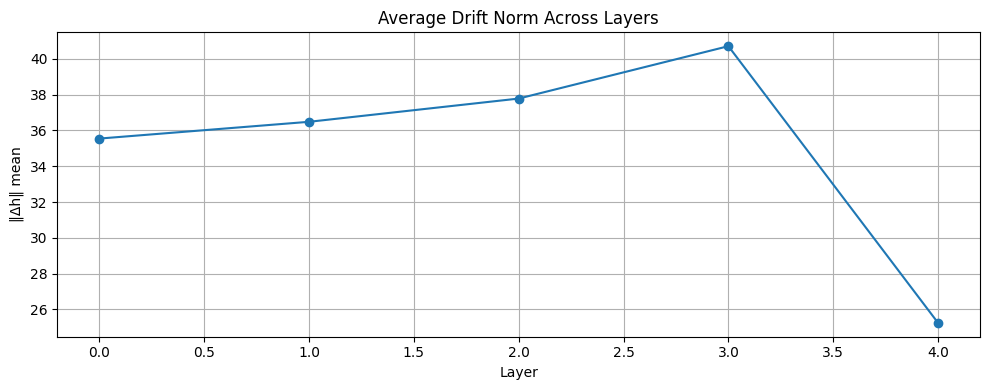

Jacobian rank (final token, projected): 37


In [80]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.autograd import grad
'''
     def forward(self, idx, targets=None):
        device = idx.device
        b, T = idx.size()

        # forward the GPT model itself
        x = self.transformer.wte(idx) # token embeddings of shape (b, t, n_embd)

        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            # if we are given some desired targets also calculate the loss
            logits = self.lm_head(x)

            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)

        else:
            # inference-time mini-optimization: only forward the lm_head on the very last position
            logits = self.lm_head(x[:, [-1], :]) # note: using list [-1] to preserve the time dim
            loss = None

        return logits, loss

'''


@torch.no_grad()
def compute_drift_trajectories(model, idx, pad_token_id=None):
    """
    Drift vectors Δh_l = h_{l+1} - h_l aligned to the shrinking time axis.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?1 default=0 if None)
    returns: list of arrays, one per layer-gap, each shaped [B]
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx
    # forward the GPT model itself



    # token + pos emb
    x =norm( model.transformer.wte(tok))
    layers = []

    with torch.no_grad():
        model.cache.reset()

        for i, block in enumerate(model.transformer.h):
            x = model.block_mem(block, x, i, model.cache.get())      # time shrinks by n_head each block (per your setup)
            model.cache.push(x)
            layers.append(x.clone()) # store aligned outputs

    # compute drifts with alignment: previous tail matches current length
    drifts = []
    for i in range(len(layers) - 1):
        a = layers[i]
        b = layers[i + 1]
        a_aligned = a[:, -b.size(1):, :]
        d = (b - a_aligned)
        drifts.append(d.norm(dim=-1).mean(dim=-1).cpu().numpy())  # [B]
    return drifts

def effective_rank(J):
    s = np.linalg.svd(J, compute_uv=False)
    s = s[s > 1e-10]
    p = s / s.sum()
    return np.exp(-np.sum(p * np.log(p)))

def compute_jacobian_rank(model, idx, projection_dim=324, pad_token_id=None):
    """
    Rank of Jacobian d logits_proj(T_final) / d emb(T_input_last) with pad-once and shrink.
    idx: [B, T_visible]
    pad_token_id: pad token id to prepend once (?2 default=0 if None)
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # embeddings with grad
    tok_emb =norm( model.transformer.wte(tok))
    emb = tok_emb
    def forward_emb(x):
        model.cache.reset()


        for i, block in enumerate(model.transformer.h):
            x = model.block_mem(block, x, i, model.cache.get())      # time shrinks by n_head each block (per your setup)
            model.cache.push(x)
        x = norm(x)
        logits =  model.lm_head(x)    # [B, T_out, V]
        return logits[:, -1, :projection_dim]  # final token after shrink, projected

    output = forward_emb(emb)         # [B, P]
    jac_rows = []
    for i in range(output.shape[-1]):
        go = torch.zeros_like(output)
        go[:, i] = 1.0
        gi = grad(output, emb, grad_outputs=go, retain_graph=True)[0]  # [B, T_all, C]
        jac_rows.append(gi[:, -1, :].detach().cpu().numpy().squeeze()) # grad w.r.t. last input step
    J = np.stack(jac_rows, axis=0)     # [P, C]
    return int(effective_rank(J))

def plot_drift(drift_norms):
    """
    Plot average drift norm per layer.
    """
    plt.figure(figsize=(10, 4))
    plt.plot([np.mean(d) for d in drift_norms], marker='o')
    plt.title("Average Drift Norm Across Layers")
    plt.xlabel("Layer")
    plt.ylabel("‖Δh‖ mean")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Example usage
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

jac_rank = compute_jacobian_rank(model, input_ids)

drift_norms = compute_drift_trajectories(model, input_ids)
plot_drift(drift_norms)

print("Jacobian rank (final token, projected):", jac_rank)

In [81]:
import torch
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def collect_drift_matrix(model, idx, pad_token_id=None):
    """
    Build a drift matrix by stacking aligned per-layer deltas:
      Δ_l = h_{l+1} - tail_match(h_l)
    Tail-match aligns time since each block trims from the left.

    idx: [B, T_visible]
    pad_token_id: ?1 left-pad token id; default 0 if None
    returns: torch.FloatTensor [N, D] on CPU where N = sum_l B * T_l
    """
    model.eval()
    device = idx.device
    B, T_vis = idx.size()

    tok = idx

    # 2) embed like forward() does
    x = norm(model.transformer.wte(tok))
    # 3) collect per-block states (time shrinks each block)
    states = []
    with torch.no_grad():
        model.cache.reset()

        for i, block in enumerate(model.transformer.h):
            x = model.block_mem(block, x, i, model.cache.get())      # time shrinks by n_head each block (per your setup)
            model.cache.push(x)
            states.append(x.clone())

    # 4) aligned drifts: match tail of h_l to h_{l+1}
    drift_chunks = []
    for i in range(len(states) - 1):
        a = states[i]       # [B, T_a, C]
        b = states[i + 1]   # [B, T_b, C], T_b <= T_a
        a_aligned = a[:, -b.size(1):, :]     # tail-match
        d = (b - a_aligned).reshape(-1, b.size(-1))  # [B*T_b, C]
        drift_chunks.append(d.cpu())

    drift_matrix = torch.cat(drift_chunks, dim=0) if drift_chunks else torch.empty(0, x.size(-1))
    return drift_matrix  # [N, D] on CPU


def run_drift_pca(drift_matrix, k=40):
    """
    PCA on drift samples. drift_matrix can be torch.Tensor [N, D] (CPU or CUDA) or np.ndarray.
    """
    if isinstance(drift_matrix, torch.Tensor):
        drift_np = drift_matrix.detach().cpu().numpy()
    else:
        drift_np = np.asarray(drift_matrix)
    k = min(k, drift_np.shape[0], drift_np.shape[1])  # guard
    pca = PCA(n_components=k)
    pca.fit(drift_np)
    explained = pca.explained_variance_ratio_
    return explained, pca


def plot_explained_variance(explained):
    plt.figure(figsize=(8, 4))
    plt.plot(np.cumsum(explained) * 100, marker='o')
    plt.xlabel("Principal Component")
    plt.ylabel("Cumulative Variance Explained (%)")
    plt.title("Drift Trajectory PCA: Explained Variance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [42]:
from sklearn.mixture import GaussianMixture
import seaborn as sns

def get_projected_residuals(drift_matrix, pca):
    """
    Project Δh onto PCA space and get residuals.
    """
    proj = pca.transform(drift_matrix.numpy())
    recon = pca.inverse_transform(proj)
    residuals = drift_matrix.numpy() - recon
    return proj, residuals

def fit_gmm(proj_data, k=4):
    """
    Fit GMM to PCA-projected drift vectors to identify latent regimes.
    """
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=0)
    gmm.fit(proj_data)
    labels = gmm.predict(proj_data)
    return gmm, labels

def plot_gmm_clusters(proj_data, labels):
    """
    Plot GMM clustering over first 2 PCA components.
    """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=proj_data[:, 0], y=proj_data[:, 1], hue=labels, palette="tab10", s=10)
    plt.title("Latent Regimes from Drift PCA (GMM Clusters)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


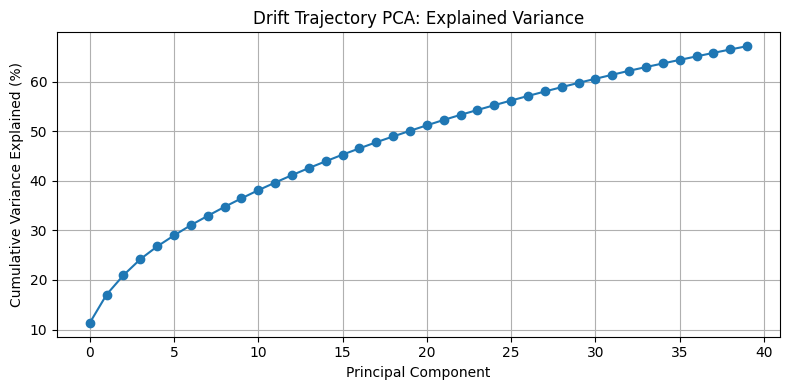

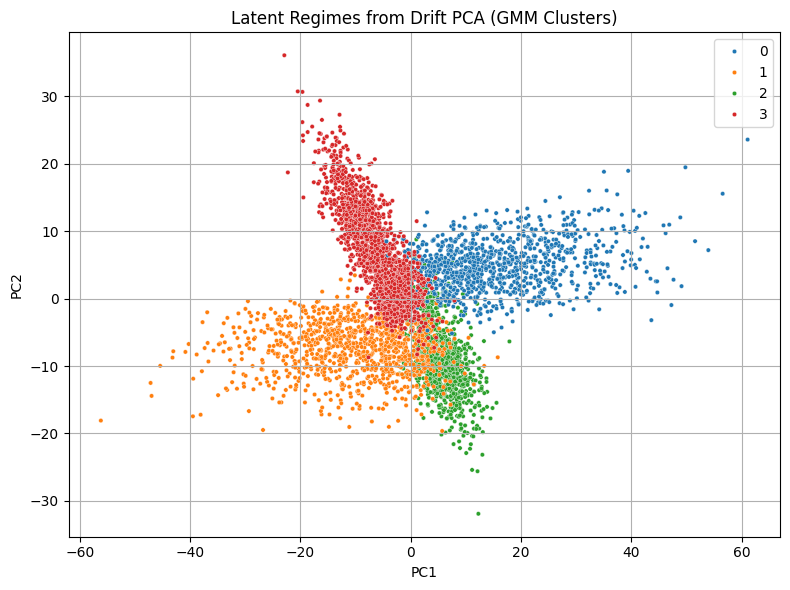

In [82]:
# Inputs
input_ids = torch.randint(0, model.config.vocab_size, (1, model.config.block_size)).to(device)

# Drift matrix
drift_matrix = collect_drift_matrix(model, input_ids)

# PCA and variance
explained, pca = run_drift_pca(drift_matrix, k=40)
plot_explained_variance(explained)

# Residuals and GMM regime fit
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=4)
plot_gmm_clusters(proj, labels)


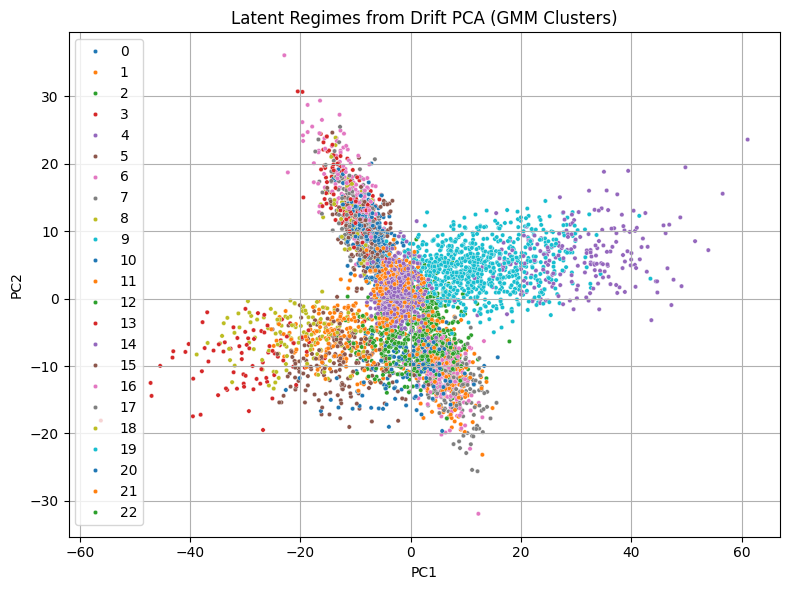

In [83]:
proj, residuals = get_projected_residuals(drift_matrix, pca)
gmm, labels = fit_gmm(proj, k=23)
plot_gmm_clusters(proj, labels)

In [84]:
import torch

def analyze_logit_magnitude(model, loader):
    # Set model to eval to disable dropout/norm updates
    model.eval()

    # Extract one batch from the loader logic provided
    iterator = iter(loader)
    xb, yb = next(iterator)

    # Mimic the unwrapping from your training loop
    if isinstance(xb, list) or (isinstance(xb, torch.Tensor) and xb.dim() > 2):
        xb = xb[0]

    # Ensure context is on the correct device
    device = next(model.parameters()).device
    context = xb.to(device)

    print(f"Context shape: {context.shape}")

    with torch.no_grad():
        # Forward pass
        logits, _ = model(context)

        # Select the logits for the last token in the sequence
        # Shape: (Batch, Time, Vocab) -> select one batch, last time step
        last_logits = logits[0, -1, :]

        max_val = last_logits.max().item()
        min_val = last_logits.min().item()
        mean_val = last_logits.mean().item()
        spread = max_val - min_val

        print("--- Logit Explosion Check ---")
        print(f"Max Logit:   {max_val:.4f}")
        print(f"Min Logit:   {min_val:.4f}")
        print(f"Mean Logit:  {mean_val:.4f}")
        print(f"Spread:      {spread:.4f}")

        # Calculate the temperature required to return this to a normal variance (assuming ~10 spread is normal)
        print(f"Effective Temp needed to normalize: {spread / 10:.2f}")
train_loader  = DataLoader(train_dataset, batch_size=1, shuffle=False, num_workers=0)

# Execute
analyze_logit_magnitude(model, train_loader)

Context shape: torch.Size([8, 1024])


/usr/local/lib/python3.12/dist-packages/torch/_functorch/_activation_checkpointing/remat_using_tags_for_fwd_loss_bwd_graph_pass.py:60: UserWarning: remat_using_tags_for_fwd_loss_bwd_graph: Graph has recomputable ops but no backward region. This may indicate a forward-only graph (e.g., from nested compilation) or missing backward annotations. Returning graph unchanged.
  warnings.warn(


--- Logit Explosion Check ---
Max Logit:   9.8632
Min Logit:   -9.4438
Mean Logit:  -4.5746
Spread:      19.3070
Effective Temp needed to normalize: 1.93


In [85]:
import random
import torch

def run_diagnostics(model, full_train_text, stoi, itos):
    print(f"--- 🧪 DIAGNOSTIC SUITE ---")

    # === TEST 1: The Verbatim Probe (Memory Check) ===
    # We grab a random sequence, feed the first half, and see if the model
    # perfectly reproduces the second half.

    seq_len = 128
    split = seq_len // 2
    samples = 5
    matches = 0

    print(f"\n[1] Verbatim Memorization Probe (n={samples})")
    print(f"    Condition: Temperature=0.00001 (Argmax proxy)")

    for i in range(samples):
        # Pick random slice
        start_idx = random.randint(0, len(full_train_text) - seq_len - 1)
        truth = full_train_text[start_idx : start_idx + seq_len]

        prompt_segment = truth[:split]
        target_segment = truth[split:]

        # Generate
        full_output = decode_sequence_char(
            model=model,
            stoi=stoi,
            itos=itos,
            prompt=prompt_segment,
            max_new_tokens=len(target_segment), # exact length match
            block_size=1024,
            temperature=1e-8 # Force greedy decoding
        )

        # Strip prompt to get just the generation
        # (Your function returns prompt + generation)
        generated_part = full_output[len(prompt_segment):]

        # Compare
        is_exact = (generated_part == target_segment)
        if is_exact: matches += 1

        status = "✅ MEMORY HIT" if is_exact else "❌ NO MATCH"
        print(f"\nSample {i+1}: {status}")
        print(f"Prompt:   {repr(prompt_segment)}")
        print(f"Expected: {repr(target_segment)}")
        print(f"Got:      {repr(generated_part)}")

    print(f"\nScore: {matches}/{samples}")
    if matches >= 4:
        print(">> RESULT: HIGH MEMORIZATION. Model is acting as a lookup table.")
    else:
        print(">> RESULT: LOW MEMORIZATION. Model is hallucinating/overfitting patterns.")

    # === TEST 2: The Adversarial Scaffold ===
    # We feed a format that looks like valid dialogue but uses tokens/names
    # that (likely) don't exist in the training set to break the lookup key.

    print(f"\n[2] Adversarial Scaffold Test")
    print("    Prompt: 'CYBERPUNK: The system is down. JULIET:'")

    scaffold = "CYBERPUNK: The system is down. JULIET:"

    adv_output = decode_sequence_char(
        model=model,
        stoi=stoi,
        itos=itos,
        prompt=scaffold,
        max_new_tokens=100,
        block_size=1024,
        temperature=1.0 # Normal sampling
    )

    print(f"    Result: {repr(adv_output[len(scaffold):])}")
    print("    Interpretation: If result is nonsense or reverts to 'ROMEO:', indexing failed.")
    print("                    If result creates a plausible Juliet line, it has generalized syntax.")

# Execute
# Assumes 'full_train' string is still in memory from your previous script.
# If not, reload it: full_train = open("babylm_10m_cleaned/shakespeare.txt").read() ...
run_diagnostics(model, full_train, stoi, itos)

--- 🧪 DIAGNOSTIC SUITE ---

[1] Verbatim Memorization Probe (n=5)
    Condition: Temperature=0.00001 (Argmax proxy)

Sample 1: ❌ NO MATCH
Prompt:   " drink a cup of sack?\n\nSecond Servant:\nWill't please your honour"
Expected: ' taste of these conserves?\n\nThird Servant:\nWhat raiment will you'
Got:      ' to the court of the country.\n\nSecond Servingman:\nWhat say you h'

Sample 2: ❌ NO MATCH
Prompt:   't not but his friends will fly to us.\n\nBLUNT:\nHe hath no friends'
Expected: ' but who are friends for fear.\nWhich in his greatest need will s'
Got:      ' that the sea that the sea there\nThat the sea the state of the s'

Sample 3: ❌ NO MATCH
Prompt:   "CHARD II:\nWhat doth our cousin lay to Mowbray's charge?\nIt must "
Expected: 'be great that can inherit us\nSo much as of a thought of ill in h'
Got:      'be so struck and the state of the state,\nAnd then the state of t'

Sample 4: ❌ NO MATCH
Prompt:   "r seen in him\nAim'd at your highness, no inveterate malice.\n\nKIN"
Expec